# Breast Cancer Diagnosis with Machine Learning
### A sensitivity-first classification pipeline with scikit-learn

**Question.** Can we predict whether a breast mass is **malignant or benign** from measurements of cell nuclei taken from a fine-needle aspirate (FNA) image — and how should we evaluate such a model when *missing a cancer is far more costly than a false alarm*?

**Approach.** Compare four supervised models with stratified cross-validation, tune the best candidates with `GridSearchCV`, then choose a **decision threshold that prioritises sensitivity** (recall for the malignant class) instead of accepting the default 0.5. The held-out test set is used exactly once, at the end.

**Contents**
1. Setup
2. The data
3. Exploratory analysis
4. Train/test split
5. Baseline: why accuracy is not enough
6. Comparing models with cross-validation
7. Hyperparameter tuning
8. Choosing a decision threshold for high sensitivity
9. Final evaluation on the held-out test set
10. What drives the predictions?
11. Limitations
12. Summary and next steps

> **Disclaimer.** This is an educational portfolio project. It is not a medical device and must not be used for clinical decisions.

## 1. Setup

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_validate, cross_val_predict, GridSearchCV
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay

RANDOM_STATE = 42
FIG_DIR = Path("../figures")
FIG_DIR.mkdir(exist_ok=True)

In [2]:
# Plot style: quiet axes, colour-blind-friendly colours used consistently
# throughout the notebook (blue = benign, orange = malignant).
BENIGN, MALIGNANT, NEUTRAL = "#2a78d6", "#eb6834", "#898781"
BLUES = LinearSegmentedColormap.from_list("blues", ["#f5f9fe", "#9ec5f4", "#2a78d6", "#104281"])
DIVERGING = LinearSegmentedColormap.from_list("div", ["#2a78d6", "#f0efec", "#eb6834"])

plt.rcParams.update({
    "figure.dpi": 110,
    "savefig.dpi": 150,
    "savefig.bbox": "tight",
    "font.size": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.edgecolor": "#c3c2b7",
    "axes.labelcolor": "#52514e",
    "axes.titleweight": "semibold",
    "axes.titlesize": 11,
    "axes.grid": True,
    "grid.color": "#e1e0d9",
    "grid.linewidth": 0.8,
    "axes.axisbelow": True,
    "xtick.color": "#52514e",
    "ytick.color": "#52514e",
    "legend.frameon": False,
    "lines.linewidth": 2,
})

## 2. The data

The **Breast Cancer Wisconsin (Diagnostic)** dataset (Wolberg, Street & Mangasarian, UCI Machine Learning Repository) contains **569 patients** and **30 numeric features**. Each feature describes the cell nuclei visible in a digitised image of a fine-needle aspirate of a breast mass.

Ten nucleus characteristics are measured — radius, texture, perimeter, area, smoothness, compactness, concavity, concave points, symmetry and fractal dimension — and for each one the dataset stores three summaries: the **mean**, the **standard error** and the **"worst"** value (mean of the three largest).

The dataset ships with scikit-learn, so this notebook runs end-to-end with no downloads.

In [3]:
data = load_breast_cancer(as_frame=True)
X = data.data

# scikit-learn encodes 0 = malignant, 1 = benign.
# In healthcare the condition we want to detect is usually the *positive* class,
# so we flip it: 1 = malignant. Now "recall" means sensitivity (share of cancers caught).
y = (data.target == 0).astype(int).rename("malignant")

print(f"{X.shape[0]} patients, {X.shape[1]} features")
X.iloc[:5, :8]

569 patients, 30 features


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430


In [4]:
print("Missing values:", int(X.isna().sum().sum()))
print()
print(y.map({0: "benign", 1: "malignant"}).rename("diagnosis").value_counts().to_string())
print(f"\nMalignant share: {y.mean():.1%}")

Missing values: 0

diagnosis
benign       357
malignant    212

Malignant share: 37.3%


In [5]:
X.describe().T[["mean", "std", "min", "max"]].round(3).loc[
    ["mean radius", "mean texture", "mean area", "mean smoothness", "worst concave points"]
]

,mean,std,min,max
mean radius,14.127,3.524,6.981,28.110
mean texture,19.290,4.301,9.710,39.280
mean area,654.889,351.914,143.500,2501.000
mean smoothness,0.096,0.014,0.053,0.163
worst concave points,0.115,0.066,0.000,0.291


**First observations**

- No missing values, so no imputation is needed.
- About **37% of cases are malignant**: the classes are moderately imbalanced, so accuracy on its own will be misleading (see section 5).
- The features live on very different scales (`mean area` is in the hundreds, `mean smoothness` around 0.1). Distance- and gradient-based models such as KNN and logistic regression need **standardised** features.

## 3. Exploratory analysis

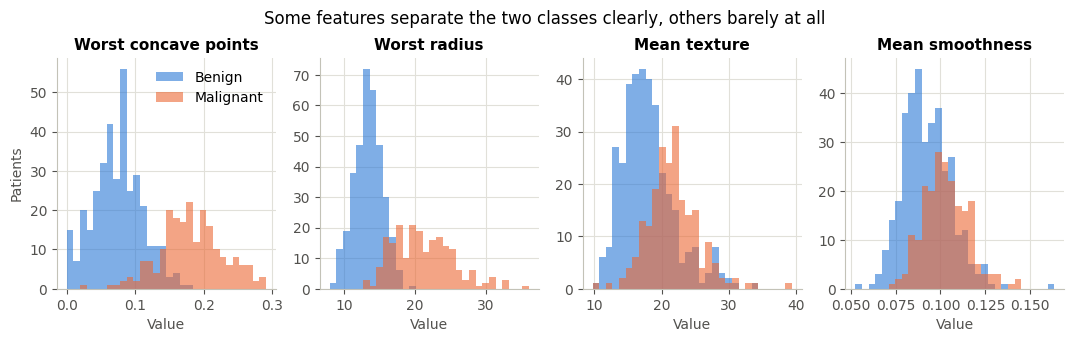

In [6]:
features = ["worst concave points", "worst radius", "mean texture", "mean smoothness"]

fig, axes = plt.subplots(1, 4, figsize=(13, 3))
for ax, feat in zip(axes, features):
    bins = np.histogram_bin_edges(X[feat], bins=30)
    ax.hist(X.loc[y == 0, feat], bins=bins, color=BENIGN, alpha=0.6, label="Benign")
    ax.hist(X.loc[y == 1, feat], bins=bins, color=MALIGNANT, alpha=0.6, label="Malignant")
    ax.set_title(feat.capitalize())
    ax.set_xlabel("Value")
axes[0].set_ylabel("Patients")
axes[0].legend(loc="upper right")
fig.suptitle("Some features separate the two classes clearly, others barely at all", y=1.04, fontsize=12)
fig.savefig(FIG_DIR / "feature_distributions.png")
plt.show()

Size and shape irregularity (**worst concave points**, **worst radius**) separate the two classes much better than **texture** or **smoothness** — consistent with how cytopathologists describe malignant nuclei (larger, more irregular).

Many features are near-duplicates of each other (radius, perimeter and area are geometrically linked). Let's check how strong the correlations are:

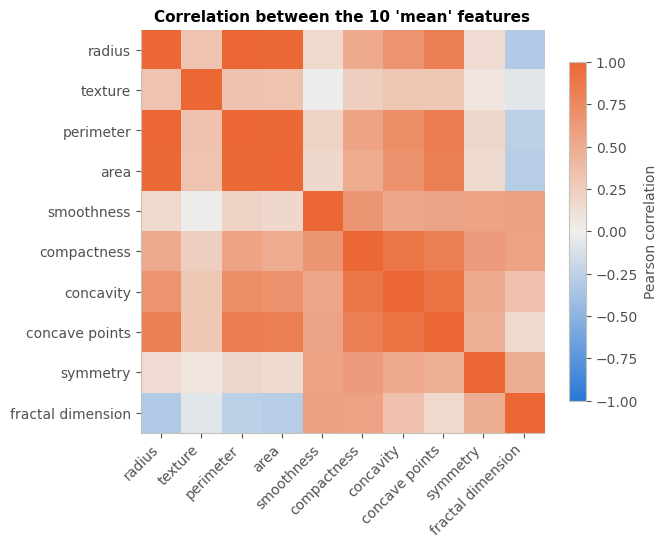

Most correlated pairs:
mean radius       mean perimeter         0.998
                  mean area              0.987
mean perimeter    mean area              0.987
mean concavity    mean concave points    0.921
mean compactness  mean concavity         0.883


In [7]:
mean_cols = [c for c in X.columns if c.startswith("mean ")]
corr = X[mean_cols].corr()

fig, ax = plt.subplots(figsize=(6.5, 5.5))
im = ax.imshow(corr, cmap=DIVERGING, vmin=-1, vmax=1)
labels = [c.replace("mean ", "") for c in mean_cols]
ax.set_xticks(range(len(labels)), labels, rotation=45, ha="right")
ax.set_yticks(range(len(labels)), labels)
ax.grid(False)
fig.colorbar(im, ax=ax, shrink=0.8, label="Pearson correlation")
ax.set_title("Correlation between the 10 'mean' features")
plt.show()

pairs = (corr.where(np.triu(np.ones(corr.shape, dtype=bool), k=1))
             .stack().sort_values(ascending=False))
print("Most correlated pairs:")
print(pairs.head(5).round(3).to_string())

Radius, perimeter and area are almost perfectly correlated (r > 0.98). This **multicollinearity** does not hurt predictive performance much, but it means we should be careful when interpreting individual coefficients later (section 10).

## 4. Train/test split

We hold out 20% of patients as a **test set** that is not touched until the final evaluation. The split is **stratified** so both sets keep the same share of malignant cases. All model selection (comparison, tuning, threshold choice) happens with cross-validation on the training set only.

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
print(f"Train: {len(X_train)} patients ({y_train.mean():.1%} malignant)")
print(f"Test:  {len(X_test)} patients ({y_test.mean():.1%} malignant)")

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

Train: 455 patients (37.4% malignant)
Test:  114 patients (36.8% malignant)


## 5. Baseline: why accuracy is not enough

A "model" that always predicts the majority class (benign) gives us a reference point.

In [9]:
baseline = DummyClassifier(strategy="most_frequent")
scores = cross_validate(baseline, X_train, y_train, cv=cv, scoring=["accuracy", "recall"])
print(f"Baseline accuracy:    {scores['test_accuracy'].mean():.1%}")
print(f"Baseline sensitivity: {scores['test_recall'].mean():.1%}")

Baseline accuracy:    62.6%
Baseline sensitivity: 0.0%


The baseline is **63% accurate while detecting zero cancers**. That is why, throughout this project, the main metrics are:

| Metric | Clinical meaning |
|---|---|
| **Sensitivity** (recall of malignant) | Of all patients with cancer, how many did we flag? A miss (false negative) can delay treatment. |
| **Specificity** | Of all patients without cancer, how many did we correctly clear? A false alarm means extra tests and anxiety. |
| **ROC AUC** | How well the model ranks malignant cases above benign ones, across *all* thresholds. |
| **Precision (PPV)** | Of the patients we flag, how many actually have cancer? |

## 6. Comparing models with cross-validation

Four models of increasing flexibility. KNN and logistic regression are wrapped in a `Pipeline` with `StandardScaler`, so that the scaler is fit **only on the training folds** of each split — scaling the full dataset first would leak information from the validation fold. Tree-based models do not need scaling.

In [10]:
models = {
    "Logistic regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=5000)),
    ]),
    "KNN": Pipeline([
        ("scaler", StandardScaler()),
        ("model", KNeighborsClassifier()),
    ]),
    "Decision tree": DecisionTreeClassifier(random_state=RANDOM_STATE),
    "Random forest": RandomForestClassifier(random_state=RANDOM_STATE),
}

scoring = ["roc_auc", "recall", "precision", "accuracy"]
cv_scores = {}
for name, model in models.items():
    cv_scores[name] = cross_validate(model, X_train, y_train, cv=cv, scoring=scoring)

comparison = pd.DataFrame(
    {name: {m: s[f"test_{m}"].mean() for m in scoring} for name, s in cv_scores.items()}
).T.rename(columns={"roc_auc": "ROC AUC", "recall": "Sensitivity",
                    "precision": "Precision", "accuracy": "Accuracy"})
comparison.sort_values("ROC AUC", ascending=False).round(3)

,ROC AUC,Sensitivity,Precision,Accuracy
Logistic regression,0.996,0.953,0.977,0.974
Random forest,0.989,0.941,0.964,0.965
KNN,0.987,0.918,0.988,0.965
Decision tree,0.917,0.894,0.900,0.923


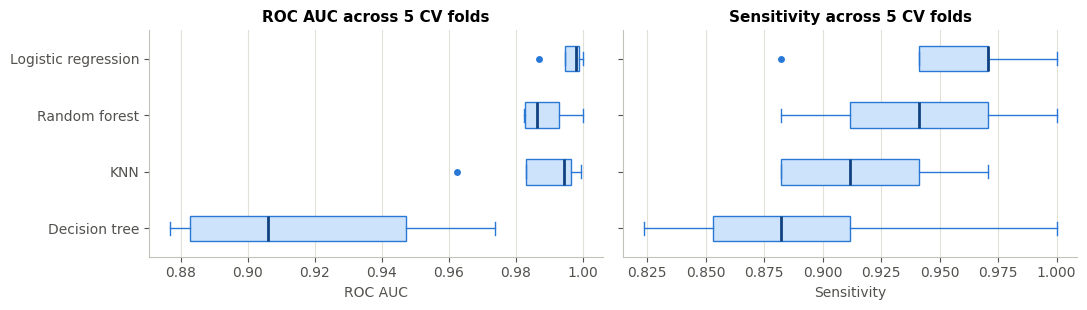

In [11]:
order = comparison.sort_values("ROC AUC").index  # best model at the top

fig, axes = plt.subplots(1, 2, figsize=(11, 3.2), sharey=True)
for ax, metric, title in zip(axes, ["roc_auc", "recall"], ["ROC AUC", "Sensitivity"]):
    values = [cv_scores[name][f"test_{metric}"] for name in order]
    ax.boxplot(values, orientation="horizontal", widths=0.45, patch_artist=True,
               boxprops=dict(facecolor="#cde2fb", edgecolor=BENIGN),
               medianprops=dict(color="#104281", linewidth=2),
               whiskerprops=dict(color=BENIGN), capprops=dict(color=BENIGN),
               flierprops=dict(marker="o", markerfacecolor=BENIGN, markeredgecolor="white", markersize=6))
    ax.set_yticks(range(1, len(order) + 1), order)
    ax.set_title(f"{title} across 5 CV folds")
    ax.set_xlabel(title)
    ax.grid(axis="y", visible=False)
fig.tight_layout()
fig.savefig(FIG_DIR / "model_comparison.png")
plt.show()

**Logistic regression** has the highest mean ROC AUC and sensitivity, and its ROC AUC varies very little between folds. The single decision tree is clearly the weakest and least stable; the random forest fixes much of that instability. With only 455 training patients and features that relate to the outcome in a fairly monotonic way ("bigger and more irregular = more likely malignant"), a simple linear model is hard to beat.

Next, we tune the three strongest candidates.

## 7. Hyperparameter tuning

`GridSearchCV` with the same 5 folds, optimising **ROC AUC** (threshold-independent — we choose the threshold separately in section 8).

- **Logistic regression:** `C`, the inverse regularisation strength.
- **KNN:** number of neighbours and whether closer neighbours get more weight.
- **Random forest:** tree depth, minimum leaf size and features considered per split.

In [12]:
param_grids = {
    "Logistic regression": {"model__C": np.logspace(-3, 2, 11).round(4).tolist()},
    "KNN": {"model__n_neighbors": range(1, 31), "model__weights": ["uniform", "distance"]},
    "Random forest": {"n_estimators": [300], "max_depth": [None, 5],
                      "min_samples_leaf": [1, 3], "max_features": ["sqrt", 0.3]},
}

searches = {}
for name, grid in param_grids.items():
    search = GridSearchCV(models[name], grid, cv=cv, scoring="roc_auc")
    search.fit(X_train, y_train)
    searches[name] = search
    print(f"{name:<20} best CV ROC AUC = {search.best_score_:.4f}   {search.best_params_}")

Logistic regression  best CV ROC AUC = 0.9958   {'model__C': 1.0}
KNN                  best CV ROC AUC = 0.9917   {'model__n_neighbors': 23, 'model__weights': 'distance'}
Random forest        best CV ROC AUC = 0.9882   {'max_depth': None, 'max_features': 0.3, 'min_samples_leaf': 1, 'n_estimators': 300}


In [13]:
best_name = max(searches, key=lambda n: searches[n].best_score_)
final_model = searches[best_name].best_estimator_
print("Selected model:", best_name)
final_model

Selected model: Logistic regression


Pipeline(steps=[('scaler', StandardScaler()),
                ('model', LogisticRegression(max_iter=5000))])

KNN gains the most from tuning (more neighbours, weighted by distance), but tuned logistic regression remains the best model, and its best `C` is the default of 1.0 — the default amount of L2 regularisation already suits this data. It is also the most **interpretable** of the candidates, which matters in a clinical setting: we can inspect exactly how each feature pushes a prediction (section 10).

## 8. Choosing a decision threshold for high sensitivity

`predict()` labels a case malignant when the predicted probability is ≥ 0.5. That cut-off treats a missed cancer and a false alarm as equally bad, which they are not. In a screening or triage setting we would rather send some extra benign cases for review than miss a malignant one.

**Rule:** pick the **highest threshold that still reaches ≥ 97% sensitivity**, so we catch almost all cancers while keeping as much specificity as possible.

To avoid peeking at the test set, the threshold is chosen from **out-of-fold predictions** on the training set: every training patient gets a probability from a model that did not see them during fitting.

In [14]:
TARGET_SENSITIVITY = 0.97

oof_proba = cross_val_predict(final_model, X_train, y_train, cv=cv, method="predict_proba")[:, 1]

def sens_spec(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return tp / (tp + fn), tn / (tn + fp)

thresholds = np.round(np.arange(0.05, 0.96, 0.01), 2)
curve = pd.DataFrame(
    [sens_spec(y_train, (oof_proba >= t).astype(int)) for t in thresholds],
    index=thresholds, columns=["sensitivity", "specificity"],
)

THRESHOLD = curve.index[curve["sensitivity"] >= TARGET_SENSITIVITY].max()
print(f"Chosen threshold: {THRESHOLD:.2f}")
curve.loc[[0.5, THRESHOLD]].round(3)

Chosen threshold: 0.31


,sensitivity,specificity
0.50,0.953,0.986
0.31,0.971,0.972


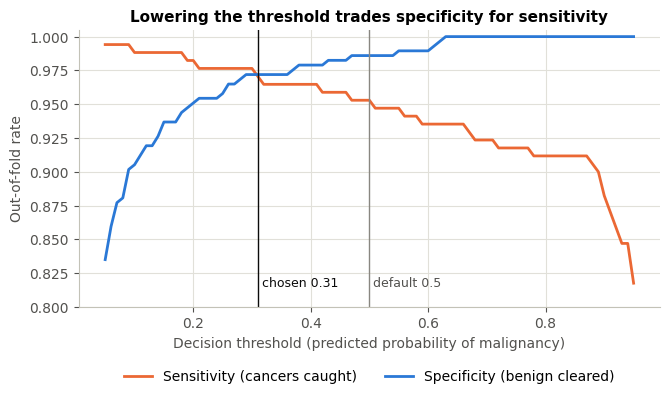

In [15]:
fig, ax = plt.subplots(figsize=(7.5, 3.6))
ax.plot(curve.index, curve["sensitivity"], color=MALIGNANT, label="Sensitivity (cancers caught)")
ax.plot(curve.index, curve["specificity"], color=BENIGN, label="Specificity (benign cleared)")
ax.axvline(0.5, color=NEUTRAL, linewidth=1)
ax.axvline(THRESHOLD, color="#0b0b0b", linewidth=1)
ax.text(0.5, 0.815, " default 0.5", color="#52514e", fontsize=9)
ax.text(THRESHOLD, 0.815, f" chosen {THRESHOLD:.2f}", color="#0b0b0b", fontsize=9)
ax.set_ylim(0.8, 1.005)
ax.set_xlabel("Decision threshold (predicted probability of malignancy)")
ax.set_ylabel("Out-of-fold rate")
ax.set_title("Lowering the threshold trades specificity for sensitivity")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.18), ncol=2)
fig.savefig(FIG_DIR / "threshold_tradeoff.png")
plt.show()

## 9. Final evaluation on the held-out test set

The final pipeline is refit on the full training set and evaluated **once** on the 114 test patients, at both the default and the chosen threshold.

In [16]:
final_model.fit(X_train, y_train)
test_proba = final_model.predict_proba(X_test)[:, 1]

def clinical_metrics(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return {
        "Sensitivity": f"{tp / (tp + fn):.1%}",
        "Specificity": f"{tn / (tn + fp):.1%}",
        "PPV (precision)": f"{tp / (tp + fp):.1%}",
        "NPV": f"{tn / (tn + fn):.1%}",
        "Missed cancers (FN)": f"{fn} of {tp + fn}",
        "False alarms (FP)": f"{fp} of {tn + fp}",
    }

results = pd.DataFrame({
    "Threshold 0.50": clinical_metrics(y_test, (test_proba >= 0.5).astype(int)),
    f"Threshold {THRESHOLD:.2f}": clinical_metrics(y_test, (test_proba >= THRESHOLD).astype(int)),
})
print(f"Test ROC AUC: {roc_auc_score(y_test, test_proba):.3f}")
results

Test ROC AUC: 0.996


,Threshold 0.50,Threshold 0.31
Sensitivity,92.9%,97.6%
Specificity,98.6%,98.6%
PPV (precision),97.5%,97.6%
NPV,95.9%,98.6%
Missed cancers (FN),3 of 42,1 of 42
False alarms (FP),1 of 72,1 of 72


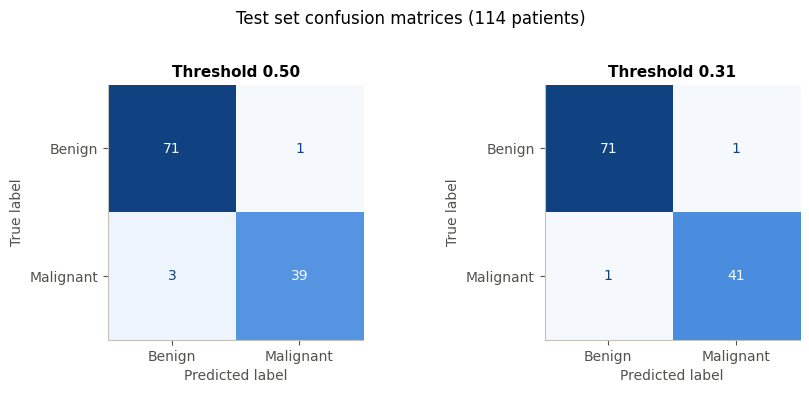

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.8))
for ax, t in zip(axes, [0.5, THRESHOLD]):
    ConfusionMatrixDisplay.from_predictions(
        y_test, (test_proba >= t).astype(int), display_labels=["Benign", "Malignant"],
        cmap=BLUES, colorbar=False, ax=ax,
    )
    ax.set_title(f"Threshold {t:.2f}")
    ax.grid(False)
fig.suptitle("Test set confusion matrices (114 patients)", y=1.02, fontsize=12)
fig.tight_layout()
fig.savefig(FIG_DIR / "confusion_matrices.png")
plt.show()

On this test set, lowering the threshold from 0.50 to the chosen value catches **2 more cancers (1 missed instead of 3 out of 42)** without adding any false alarms. On new data the trade-off will not always be this favourable: the out-of-fold analysis in section 8 suggests a small specificity cost (98.6% → 97.2%) in exchange for the sensitivity gain (95.3% → 97.1%).

With only 114 test patients (42 malignant), a single miss moves sensitivity by more than 2 percentage points. To show how much uncertainty is behind these numbers, we **bootstrap** the test set: resample patients with replacement 2,000 times and recompute the metrics each time.

In [18]:
rng = np.random.default_rng(RANDOM_STATE)
y_arr, p_arr = y_test.to_numpy(), test_proba
boot = []
for _ in range(2000):
    idx = rng.integers(0, len(y_arr), len(y_arr))
    yb, pb = y_arr[idx], p_arr[idx]
    if yb.min() == yb.max():
        continue
    sens, spec = sens_spec(yb, (pb >= THRESHOLD).astype(int))
    boot.append({"ROC AUC": roc_auc_score(yb, pb), "Sensitivity": sens, "Specificity": spec})
boot = pd.DataFrame(boot)

point = {
    "ROC AUC": roc_auc_score(y_test, test_proba),
    **dict(zip(["Sensitivity", "Specificity"], sens_spec(y_test, (test_proba >= THRESHOLD).astype(int)))),
}
ci = pd.DataFrame({
    "Estimate": point,
    "95% CI low": boot.quantile(0.025),
    "95% CI high": boot.quantile(0.975),
})
print(f"Test-set metrics at threshold {THRESHOLD:.2f}, with bootstrap 95% confidence intervals:")
ci.round(3)

Test-set metrics at threshold 0.31, with bootstrap 95% confidence intervals:


,Estimate,95% CI low,95% CI high
ROC AUC,0.996,0.986,1.0
Sensitivity,0.976,0.921,1.0
Specificity,0.986,0.952,1.0


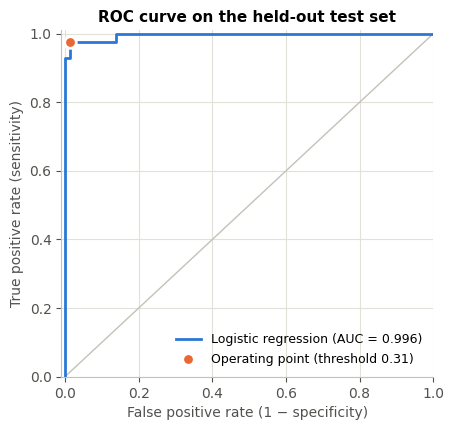

In [19]:
fpr, tpr, roc_thr = roc_curve(y_test, test_proba)
op_sens, op_spec = sens_spec(y_test, (test_proba >= THRESHOLD).astype(int))

fig, ax = plt.subplots(figsize=(4.8, 4.5))
ax.plot([0, 1], [0, 1], color="#c3c2b7", linewidth=1)
ax.plot(fpr, tpr, color=BENIGN, label=f"Logistic regression (AUC = {roc_auc_score(y_test, test_proba):.3f})")
ax.scatter([1 - op_spec], [op_sens], s=70, color=MALIGNANT, edgecolor="white", linewidth=2, zorder=3,
           label=f"Operating point (threshold {THRESHOLD:.2f})")
ax.set_xlabel("False positive rate (1 − specificity)")
ax.set_ylabel("True positive rate (sensitivity)")
ax.set_title("ROC curve on the held-out test set")
ax.legend(loc="lower right", fontsize=9)
ax.set_xlim(-0.01, 1)
ax.set_ylim(0, 1.01)
fig.savefig(FIG_DIR / "roc_curve.png")
plt.show()

## 10. What drives the predictions?

Because the features are standardised, each logistic-regression coefficient is the change in the **log-odds of malignancy for a one-standard-deviation increase** in that feature, holding the others fixed. Positive coefficients push towards malignant, negative towards benign.

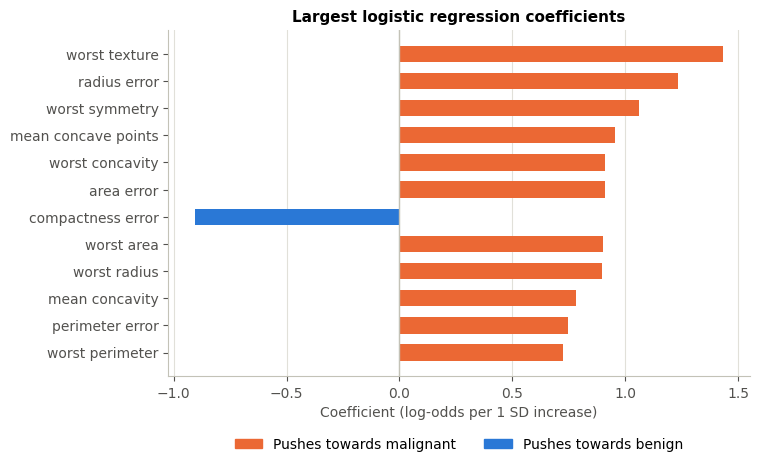

In [20]:
coefs = pd.Series(final_model.named_steps["model"].coef_[0], index=X.columns)
top = coefs.reindex(coefs.abs().sort_values(ascending=False).index).head(12)[::-1]

fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.barh(top.index, top.values, height=0.6,
        color=[MALIGNANT if v > 0 else BENIGN for v in top.values])
ax.axvline(0, color="#c3c2b7", linewidth=1)
ax.set_xlabel("Coefficient (log-odds per 1 SD increase)")
ax.set_title("Largest logistic regression coefficients")
ax.legend(handles=[plt.Rectangle((0, 0), 1, 1, color=MALIGNANT), plt.Rectangle((0, 0), 1, 1, color=BENIGN)],
          labels=["Pushes towards malignant", "Pushes towards benign"],
          loc="upper center", bbox_to_anchor=(0.5, -0.14), ncol=2)
ax.grid(axis="y", visible=False)
fig.savefig(FIG_DIR / "feature_coefficients.png")
plt.show()

**How to read this — with care.**

- The largest positive coefficients belong to **texture, variability of nucleus size (radius error), asymmetry and concavity**, plus the "worst" size features. This matches the clinical picture from section 3: malignant nuclei tend to be larger, more irregular and more variable.
- The size signal is **spread across** radius, perimeter and area, each with a moderate weight, because the three features carry almost the same information.
- Some signs are **counter-intuitive**. Compactness features get *negative* coefficients, even though malignant tumours have higher compactness on average (checked below). Once concavity and concave points are in the model, compactness mostly adds information *conditional* on them, so its coefficient can flip sign. This is a classic effect of multicollinearity.
- Individual coefficients should therefore **not** be read as causal effects, or used on their own to explain a single patient's result. A more robust next step would be permutation importance on grouped features, or a model on a reduced, less redundant feature set.

In [21]:
# Univariate check: compactness is clearly higher in malignant cases...
print(X.groupby(y.map({0: "benign", 1: "malignant"}).rename("diagnosis"))[["mean compactness", "compactness error"]].mean().round(3))
print()
# ...yet its coefficient in the multivariable model is negative
print(coefs[["mean compactness", "compactness error"]].round(3).to_string())

           mean compactness  compactness error
diagnosis                                     
benign                0.080              0.021
malignant             0.145              0.032

mean compactness    -0.440
compactness error   -0.907


## 11. Limitations

- **Small, single-centre, historical dataset.** 569 patients from one institution (University of Wisconsin, early 1990s). Performance would need to be confirmed on an **external** cohort before drawing any clinical conclusions.
- **Features depend on a human step.** The nucleus measurements come from image regions selected by an operator, so the pipeline is not fully automatic and results may depend on who prepares the images.
- **Small test set.** With 42 malignant test cases, the confidence intervals in section 9 are wide; a single additional miss changes sensitivity noticeably.
- **No demographic information.** We cannot check whether the model performs equally well across age groups or populations — an important fairness check for any real clinical model.
- **Threshold choice is a clinical decision.** The 97% sensitivity target is an illustrative assumption. In practice it should be set with clinicians, based on the real cost of missed diagnoses versus unnecessary follow-up.
- **Calibration was not assessed.** If predicted probabilities were shown to clinicians as risks, they would first need to be checked for calibration.

## 12. Summary and next steps

**What was done**

- Framed the task clinically: malignant = positive class, sensitivity as the primary metric.
- Built leakage-free `Pipeline`s (scaling inside cross-validation) and compared four models with stratified 5-fold CV.
- Tuned models with `GridSearchCV`; a regularised **logistic regression** performed best and is also the most interpretable.
- Chose the decision threshold from **out-of-fold** predictions to reach ≥ 97% sensitivity, instead of accepting the default 0.5.
- Evaluated once on a held-out test set and reported **bootstrap confidence intervals**, not just point estimates.

**Next steps**

- Probability calibration (`CalibratedClassifierCV`, reliability curve).
- Feature selection or grouping to reduce redundancy and make interpretation more stable.
- Repeated cross-validation / nested CV for a less noisy estimate of generalisation performance.
- Apply the same workflow to a messier real-world dataset with missing values and categorical variables (e.g. hospital readmission data).